# Trying Forward Model on Requested Protocol.

## Preparing the notebook.

### Importing the libraries.

In [1]:
import sys
import yaml

from anndata import AnnData
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scanpy as sc
from scipy.spatial.distance import cdist
from scipy.special import softmax
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.neighbors import NearestNeighbors
import torch
from tqdm import tqdm

from sc_exp_design.constants import DataFields, ParamsFields, PredictionFields
from sc_exp_design.data.container import DataMixin
from sc_exp_design.models import FlowMatching, TargetPredictionModel

### Constants.

In [2]:
BASE_DIR = "/lustre/groups/ml01/workspace/lorenzo.consoli/projects/SFC_cambridge/collab-goettgens-SFC"

# CELLULAR_RESPONSE_MODEL_PATH = "/lustre/groups/ml01/workspace/lorenzo.consoli/projects/SFC_cambridge/dumps/2025-11-14_15-15-26/sage-energy-324_FlowMatching.pkl"
# CELLULAR_RESPONSE_MODEL_PATH = "/lustre/groups/ml01/workspace/lorenzo.consoli/projects/SFC_cambridge/dumps/2025-11-14_15-15-26/lively-smoke-29_FlowMatching.pkl"
# CELLULAR_RESPONSE_MODEL_PATH = "/lustre/groups/ml01/workspace/lorenzo.consoli/projects/SFC_cambridge/dumps/2025-11-14_15-15-26/fast-eon-166_FlowMatching.pkl"
# CELLULAR_RESPONSE_MODEL_PATH = "/lustre/groups/ml01/workspace/lorenzo.consoli/projects/SFC_cambridge/dumps/2025-12-14_11-53-04/firm-brook-15_FlowMatching.pkl"
CELLULAR_RESPONSE_MODEL_PATH = "/lustre/groups/ml01/workspace/lorenzo.consoli/projects/SFC_cambridge/dumps/2025-12-14_11-53-04/cerulean-durian-19_FlowMatching.pkl"

TARGET_PREDICTION_MODEL_PATH = "/lustre/groups/ml01/workspace/lorenzo.consoli/projects/SFC_cambridge/dumps/2025-11-14_21-22-45/dashing-frog-1258_TargetPredictionModel.pkl"

ANNOTATION_YAML_PATH = "/lustre/groups/ml01/workspace/lorenzo.consoli/projects/SFC_cambridge/collab-goettgens-SFC/generative_modeling/conditional_flow_matching/config/annotation/default.yaml"
cell_state_rep = "X_channel_standardized+X_scatter_standardized"

### Importing Additional Modules.


In [3]:
sys.path.insert(0, f"{BASE_DIR}/inverse/inverse_utils")
sys.path.insert(0, f"{BASE_DIR}/model_utils")
sys.path.insert(0, f"{BASE_DIR}/scripts")
from forward_model import ForwardModel
from z_norm_modules import ZNorm, IZNorm, RescaledTargetPredictionModel
from data_utils import annotate_perturbations, get_protocol_tranformations

### Utility functions.

In [4]:
def plot_marginals(X_real, X_gen=None, col_names=None, title=""):
    n_channels = X_real.shape[1]
    if X_gen is not None:
        assert X_gen.shape[1] == n_channels
    if col_names is not None:
        assert len(col_names) == n_channels

    fig, ax = plt.subplots(1, n_channels, figsize=(45, 5))
    fig.suptitle(f"{title}", fontsize=16)
    for i in range(n_channels):
        ax[i].grid(True)
        sns.kdeplot(X_real[:, i], ax=ax[i], color="green", label="real")
        if X_gen is not None:
            sns.kdeplot(X_gen[:, i], ax=ax[i], color="red", label="gen")
        ax[i].legend()
        if col_names is not None:
            ax[i].set_title(col_names[i])
    fig.tight_layout(rect=[0, 0, 1, 0.95])
    return fig

def generated_density_knn(X_true, X_generated, k=20, bandwidth=None):

    nbrs = NearestNeighbors(n_neighbors=k).fit(X_true)
    distances, indices = nbrs.kneighbors(X_generated)
    
    # Auto-bandwidth: median distance of neighbors
    if bandwidth is None:
        bandwidth = np.median(distances)

    density = np.zeros(X_true.shape[0])

    # Gaussian kernel weights
    weights = np.exp(-(distances**2) / (2 * bandwidth**2))

    # Add weighted contributions
    for gen_idx in range(len(X_generated)):
        for neighbor_pos, real_idx in enumerate(indices[gen_idx]):
            density[real_idx] += weights[gen_idx, neighbor_pos]

    return density

### Defining protocol of interest.

In [5]:
protocol_dict = {
    "740-yp_[µm]": [5.0,], # only one value
    "mtg_[µm]": [100.0,], # only one value
    "rhflt3l_[ng_ml]": [10.0,], # only one value
    "gm-csf_[ng_ml]": [10.0,], # seen
    "tpo_[ng_ml]": [2.5,], # seen
    "sr1_[nm]": [75.0,], # seen
    "um171_[nm]": [560.0,], # seen
    "um729_[µm]": [0.0,], # seen
    "scf_[ng_ml]": [10.0,], # seen
    "butyzamide_[nm]": [0.0,], # seen
    "retinoic_acid_[µm]": [0.0,], # seen
    "ldl_[ng_ml]": [0.0,], # seen
    "il3_[ng_ml]": [0.0,], # seen
    "o2_[%]": [20.0,], # seen
    "days_of_culture": [14.0,] # seen
}
protocol_df = pd.DataFrame(protocol_dict)
protocol_df

,740-yp_[µm],mtg_[µm],rhflt3l_[ng_ml],gm-csf_[ng_ml],tpo_[ng_ml],sr1_[nm],um171_[nm],um729_[µm],scf_[ng_ml],butyzamide_[nm],retinoic_acid_[µm],ldl_[ng_ml],il3_[ng_ml],o2_[%],days_of_culture
0,5.0,100.0,10.0,10.0,2.5,75.0,560.0,0.0,10.0,0.0,0.0,0.0,0.0,20.0,14.0


### Reading annotation file.

In [6]:
with open(ANNOTATION_YAML_PATH, "r") as fb:
    annotation_dict = yaml.safe_load(fb)
print(annotation_dict)

{'protocol_columns': ['740-yp_[µm]', 'mtg_[µm]', 'rhflt3l_[ng_ml]', 'gm-csf_[ng_ml]', 'tpo_[ng_ml]', 'sr1_[nm]', 'um171_[nm]', 'um729_[µm]', 'scf_[ng_ml]', 'butyzamide_[nm]', 'retinoic_acid_[µm]', 'ldl_[ng_ml]', 'il3_[ng_ml]', 'o2_[%]', 'days_of_culture'], 'protocol_obs_key_added': 'protocol_id', 'protocol_sep': '_', 'one_hot_uns_key_added': 'one_hot', 'protocol_obsm_key': 'condition_concat', 'scatter_columns': ['FSC - Area', 'FSC - Height', 'FSC - Width', 'SSC - Area', 'SSC - Height', 'SSC - Width'], 'base_sample_rep': None, 'scatter_obsm_key': 'X_scatter', 'concat_obsm_key': 'X_concat', 'log1p_exp_cols': ['um171_[nm]', 'um729_[µm]', 'scf_[ng_ml]', 'butyzamide_[nm]', 'o2_[%]', 'sr1_[nm]', 'mtg_[µm]', 'rhflt3l_[ng_ml]', 'gm-csf_[ng_ml]', 'days_of_culture'], 'log21p_exp_cols': ['il3_[ng_ml]', 'retinoic_acid_[µm]', 'tpo_[ng_ml]']}


### Retrieving the number of scatter features.

In [7]:
scatter_columns = annotation_dict["scatter_columns"]
n_scatter_feats = len(scatter_columns)
print(f"{n_scatter_feats=}")

n_scatter_feats=6


## Loading Models.

### Loading Cellular Response Prediction Model.

(<Figure size 300x300 with 1 Axes>, <Axes: title={'center': 'loss'}>)

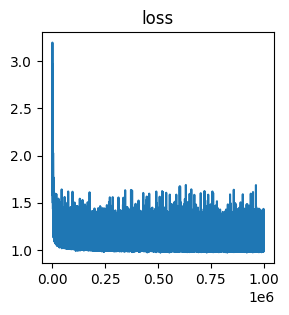

In [8]:
flow_matching = FlowMatching.load(CELLULAR_RESPONSE_MODEL_PATH)
flow_matching.trainer.plot_training_logs()

### Loading Target Prediction Model.

(<Figure size 300x300 with 1 Axes>, <Axes: title={'center': 'loss'}>)

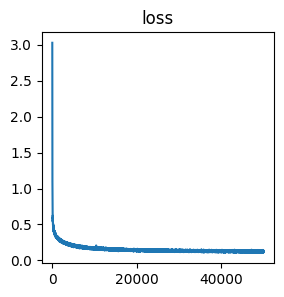

In [9]:
g_model =  TargetPredictionModel.load(TARGET_PREDICTION_MODEL_PATH)
ct_le = LabelEncoder().fit(g_model.train_data.adata.obs["cell_type"].values)
g_model.target_predictor_trainer.plot_training_logs()

## Preparing rescaled model.

### Inverse Z transform from Cellular Response Prediction Model.

In [10]:
X_channel_params_inv = flow_matching.train_data.adata.uns["X_channel_params"]
X_scatter_params_inv = flow_matching.train_data.adata.uns["X_scatter_params"]
params_inv = {
    ParamsFields.MEAN: torch.from_numpy(
        np.concatenate(
            (
                X_channel_params_inv[ParamsFields.MEAN],
                X_scatter_params_inv[ParamsFields.MEAN]
            ), axis=0
        )
    ),
    ParamsFields.COVARIANCE: torch.from_numpy(
        np.concatenate(
            (
                X_channel_params_inv["std"],
                X_scatter_params_inv["std"]
            ), axis=0
        )
    ),
}
izn = IZNorm(params_inv)
izn

IZNorm(
  (params): ModuleDict(
    (mean): ModelParam()
    (covariance): ModelParam()
  )
)

### Z Transform from Target Prediction Model.

In [11]:
X_channel_params_fwd = g_model.train_data.adata.uns["X_channel_params"]
X_scatter_params_fwd = g_model.train_data.adata.uns["X_scatter_params"]
params_fwd = {
    ParamsFields.MEAN: torch.from_numpy(
        np.concatenate(
            (
                X_channel_params_fwd[ParamsFields.MEAN],
                X_scatter_params_fwd[ParamsFields.MEAN]
            ), axis=0
        )
    ),
    ParamsFields.COVARIANCE: torch.from_numpy(
        np.concatenate(
            (
                X_channel_params_fwd["std"],
                X_scatter_params_fwd["std"]
            ), axis=0
        )
    ),
}
zn = ZNorm(params_fwd)
zn

ZNorm(
  (params): ModuleDict(
    (mean): ModelParam()
    (covariance): ModelParam()
  )
)

### Initializing rescaled model.

In [12]:
g_model_rescaled = RescaledTargetPredictionModel(
    g_model.target_prediction_model,
    inv_params=izn,
    fwd_params=zn
)
g_model_rescaled

RescaledTargetPredictionModel(
  (resc_model): ModuleDict(
    (inv_params): IZNorm(
      (params): ModuleDict(
        (mean): ModelParam()
        (covariance): ModelParam()
      )
    )
    (fwd_params): ZNorm(
      (params): ModuleDict(
        (mean): ModelParam()
        (covariance): ModelParam()
      )
    )
    (model): PerturbationApproximatePosterior(
      (pert_approximate_posterior): ModuleDict(
        (encoder): MLPBlock(
          (net): Sequential(
            (0): Sequential(
              (0): Linear(in_features=27, out_features=2048, bias=True)
              (1): ReLU()
              (2): Dropout(p=0.75, inplace=False)
            )
            (1): Sequential(
              (0): Linear(in_features=2048, out_features=2048, bias=True)
              (1): ReLU()
              (2): Dropout(p=0.75, inplace=False)
            )
            (2): Sequential(
              (0): Linear(in_features=2048, out_features=2048, bias=True)
              (1): ReLU()
            

### Initializing forward model.

In [13]:
forward_model = ForwardModel(
    forward_model=flow_matching,
    target_prediction_model=g_model_rescaled,
)

## Preparing annotated data from subsample.

### Retrieving train and validation data from model.

In [14]:
train_adata_g = g_model.train_data.adata
val_adata_g = g_model.validation_data.adata
train_adata_g, val_adata_g

(AnnData object with n_obs × n_vars = 70000 × 21
     obs: 'replicate', 'date', 'cytometer', 'cytometer_serial_no', 'well_id', 'count_beads', 'cell_counts', 'experiment_number', 'experiment_id', '740-yp_[µm]', 'mtg_[µm]', 'rhflt3l_[ng_ml]', 'gm-csf_[ng_ml]', 'tpo_[ng_ml]', 'sr1_[nm]', 'um171_[nm]', 'um729_[µm]', 'scf_[ng_ml]', 'butyzamide_[nm]', 'retinoic_acid_[µm]', 'ldl_[ng_ml]', 'il3_[ng_ml]', 'source_id', 'hydrogel_type', 'o2_[%]', 'source_cell_phenotype', 'total_count_beads', 'counts_source_cell_phenotype', 'days_of_culture', 'plate', 'absolute_number_multiplier_[2^n]', 'cytometer_id', 'FSC - Area', 'FSC - Height', 'FSC - Width', 'SSC - Area', 'SSC - Height', 'SSC - Width', 'Time Stamp', 'batch', 'leiden', 'cell_type'
     var: 'n', 'channel', 'marker', '$PnD', '$PnB', '$PnR', '$PnG', '$PnE', 'signal_type', 'antibody'
     uns: 'cell_type_colors', 'leiden', 'leiden_colors', 'meta', 'neighbors', 'processing_steps', 'umap', 'pca', 'X_scatter_params', 'X_channel_params'
     obsm: 'X

### Preparing obs.

In [15]:
obs_df = pd.concat((train_adata_g.obs, val_adata_g.obs), axis=0)
obs_df.head()

,replicate,date,cytometer,cytometer_serial_no,well_id,count_beads,cell_counts,experiment_number,experiment_id,740-yp_[µm],...,FSC - Area,FSC - Height,FSC - Width,SSC - Area,SSC - Height,SSC - Width,Time Stamp,batch,leiden,cell_type
50729-586,3,26-MAR-2025,LE-ID7000C,2803032,B03,1328,152087,2139,LPHO05,5,...,581687.81250,267480.0,278.210205,370031.531250,192467.0,245.749039,17.103960,586,1,GMP-Neutro
279080-443,3,12-MAR-2025,LE-ID7000C,2803032,C03,690,760395,150,LPHO05,5,...,363987.78125,182598.5,255.050766,238706.109375,139004.0,220.166245,44.191700,443,3,pDCs/cDCs
104800-260,3,06-DEC-2024,LE-ID7000C,2803032,E10,1061,182904,1178,LPHO03b,5,...,223356.62500,126678.0,227.599045,96156.742188,65047.5,190.458679,30.507099,260,2,GMP-Cycle
672265-441,1,12-MAR-2025,LE-ID7000C,2803032,A03,762,720448,150,LPHO05,5,...,424493.75000,225887.0,240.445740,361305.531250,199324.5,232.395874,98.853760,441,0,MPP
77941-94,2,24-JAN-2025,LE-ID7000C,2803032,C05,1240,258736,1113,JAR02,5,...,353198.84375,182971.5,251.028214,323987.031250,197090.5,214.089310,14.433980,94,2,GMP-Cycle


### Retrieving representation.

In [16]:
X_train_g_model = train_adata_g.obsm[cell_state_rep]
X_val_g_model = val_adata_g.obsm[cell_state_rep]

### Inverse z-standardization from train data.

In [17]:
izn_g = IZNorm(params_fwd)
izn_g

IZNorm(
  (params): ModuleDict(
    (mean): ModelParam()
    (covariance): ModelParam()
  )
)

### Z-standardization from flow matching model.

In [18]:
zn_phi = ZNorm(params_inv)
zn_phi

ZNorm(
  (params): ModuleDict(
    (mean): ModelParam()
    (covariance): ModelParam()
  )
)

### Applying tranformation to data.

In [19]:
X_train_g = izn_g(torch.from_numpy(X_train_g_model).cuda())
X_train_g = zn_phi(X_train_g).detach().cpu().numpy()
X_val_g = izn_g(torch.from_numpy(X_val_g_model).cuda())
X_val_g = zn_phi(X_val_g).detach().cpu().numpy()
X_g = np.concatenate((X_train_g, X_val_g), axis=0)
print(f"{X_g.shape=}")

X_g.shape=(100000, 27)


## Preparing condition data.

### Preparing dummy adata.

In [20]:
dummy_adata = AnnData(
    X=np.empty((1, 2)),
    obs=protocol_df
)

/home/icb/lorenzo.consoli/miniconda3/envs/sc_exp_design/lib/python3.12/site-packages/anndata/_core/aligned_df.py:68: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)


### Retrieving transforms.

In [21]:
column2tranform = get_protocol_tranformations(
    annotation_dict["protocol_columns"],
    log1p_exp_cols=annotation_dict["log1p_exp_cols"],
    log21p_exp_cols=annotation_dict["log21p_exp_cols"]
)

### Annotating perturbations.

In [22]:
annotate_perturbations(
    dummy_adata,
    annotation_dict["protocol_columns"],
    annotation_dict["protocol_obs_key_added"],
    protocol_sep=annotation_dict["protocol_sep"],
    one_hot_uns_key_added=annotation_dict["one_hot_uns_key_added"],
    column2tranform=column2tranform,
    protocol_obsm_key=annotation_dict["protocol_obsm_key"]
)
dummy_adata


AnnData object with n_obs × n_vars = 1 × 2
    obs: '740-yp_[µm]', 'mtg_[µm]', 'rhflt3l_[ng_ml]', 'gm-csf_[ng_ml]', 'tpo_[ng_ml]', 'sr1_[nm]', 'um171_[nm]', 'um729_[µm]', 'scf_[ng_ml]', 'butyzamide_[nm]', 'retinoic_acid_[µm]', 'ldl_[ng_ml]', 'il3_[ng_ml]', 'o2_[%]', 'days_of_culture', 'protocol_id'
    uns: 'one_hot', '740-yp_[µm]_one_hot', 'mtg_[µm]_one_hot', 'rhflt3l_[ng_ml]_one_hot', 'gm-csf_[ng_ml]_one_hot', 'tpo_[ng_ml]_one_hot', 'sr1_[nm]_one_hot', 'um171_[nm]_one_hot', 'um729_[µm]_one_hot', 'scf_[ng_ml]_one_hot', 'butyzamide_[nm]_one_hot', 'retinoic_acid_[µm]_one_hot', 'ldl_[ng_ml]_one_hot', 'il3_[ng_ml]_one_hot', 'o2_[%]_one_hot', 'days_of_culture_one_hot'
    obsm: '740-yp_[µm]', 'mtg_[µm]', 'rhflt3l_[ng_ml]', 'gm-csf_[ng_ml]', 'tpo_[ng_ml]', 'sr1_[nm]', 'um171_[nm]', 'um729_[µm]', 'scf_[ng_ml]', 'butyzamide_[nm]', 'retinoic_acid_[µm]', 'ldl_[ng_ml]', 'il3_[ng_ml]', 'o2_[%]', 'days_of_culture', 'condition_concat'

### Preparing perturbation data schema.

In [23]:
protocol_data = flow_matching.data_manager.perturbation_data_schema.get_data(dummy_adata)
protocol_data = DataMixin(protocol_data)
protocol_data = protocol_data.apply(
    lambda x: torch.from_numpy(x).float().to(flow_matching.device)
)
protocol_data

{'feats_condition_concat_condition_concat': tensor([[5.0000, 4.6151, 2.3979, 2.3979, 1.8074, 4.3307, 6.3297, 0.0000, 2.3979,
          0.0000, 0.0000, 0.0000, 0.0000, 3.0445, 2.7081]], device='cuda:0')}

## Generating with the forward model.

### Running Predictions.

In [24]:
num_samples = 50_000
num_time_steps = 500
solver_kwargs = {"method": "euler"}
prediction_dict = forward_model.predict(
    {
        DataFields.PERTURBATION_DATA: protocol_data
    },
    num_samples=num_samples,
    num_time_steps=num_time_steps,
    solver_kwargs=solver_kwargs,
)
X_hat = prediction_dict.pop("predicted_states").squeeze().detach().cpu().numpy()
G_logits = prediction_dict.pop("target_prediction_data")["cell_type"].squeeze().detach().cpu().numpy()
G_probs = softmax(G_logits, axis=1)
G_id = G_probs.argmax(1)
G_label = ct_le.inverse_transform(G_id)

# splitting channel and scatter features
X_channel = X_hat[:, :-n_scatter_feats]
X_scatter = X_hat[:, -n_scatter_feats:]
print(f"{X_hat.shape=}, {X_channel.shape=}, {X_scatter.shape=}, {G_logits.shape=}, {G_probs.shape=}, {G_id.shape=}, {G_label.shape=}")

X_hat.shape=(50000, 27), X_channel.shape=(50000, 21), X_scatter.shape=(50000, 6), G_logits.shape=(50000, 19), G_probs.shape=(50000, 19), G_id.shape=(50000,), G_label.shape=(50000,)


### Subsampling the real data.

In [25]:
n_train_cells = 100_000
n_val_cells = 30_000
train_adata_fwd = sc.pp.sample(
    flow_matching.train_data.adata,
    n=n_train_cells,
    copy=True
)
val_adata_fwd = sc.pp.sample(
    next(iter(flow_matching.validation_data.values())).adata,
    n=n_val_cells,
    copy=True
)
print(f"{train_adata_fwd=}, {val_adata_fwd=}")

train_adata_fwd=AnnData object with n_obs × n_vars = 100000 × 21
    obs: 'replicate', 'date', 'cytometer', 'cytometer_serial_no', 'well_id', 'count_beads', 'cell_counts', 'experiment_number', 'experiment_id', '740-yp_[µm]', 'mtg_[µm]', 'rhflt3l_[ng_ml]', 'gm-csf_[ng_ml]', 'tpo_[ng_ml]', 'sr1_[nm]', 'um171_[nm]', 'um729_[µm]', 'scf_[ng_ml]', 'butyzamide_[nm]', 'retinoic_acid_[µm]', 'ldl_[ng_ml]', 'il3_[ng_ml]', 'source_id', 'hydrogel_type', 'o2_[%]', 'source_cell_phenotype', 'total_count_beads', 'counts_source_cell_phenotype', 'days_of_culture', 'plate', 'absolute_number_multiplier_[2^n]', 'cytometer_id', 'FSC - Area', 'FSC - Height', 'FSC - Width', 'SSC - Area', 'SSC - Height', 'SSC - Width', 'Time Stamp', 'batch', 'protocol_id'
    var: 'n', 'channel', 'marker', '$PnD', '$PnB', '$PnR', '$PnG', '$PnE', 'signal_type', 'antibody'
    uns: 'meta', 'processing_steps', 'one_hot', '740-yp_[µm]_one_hot', 'mtg_[µm]_one_hot', 'rhflt3l_[ng_ml]_one_hot', 'gm-csf_[ng_ml]_one_hot', 'tpo_[ng_ml]_on

### Predicting cell type on rest of data.

In [26]:
X_train = train_adata_fwd.obsm[cell_state_rep]
X_val = val_adata_fwd.obsm[cell_state_rep]
g_model_rescaled.eval()
with torch.no_grad():
    G_logits_train = g_model_rescaled(
        torch.from_numpy(X_train).float().to("cuda")
    )["cell_type"].detach().cpu().numpy()
    G_logits_val = g_model_rescaled(
        torch.from_numpy(X_val).float().to("cuda")
    )["cell_type"].detach().cpu().numpy()
G_probs_train = softmax(G_logits_train, axis=1)
G_probs_val = softmax(G_logits_val, axis=1)
G_id_train = G_probs_train.argmax(1)
G_id_val = G_probs_val.argmax(1)
G_label_train = ct_le.inverse_transform(G_id_train)
G_label_val = ct_le.inverse_transform(G_id_val)
print(f"{G_logits_train.shape=}, {G_logits_val.shape=}, {G_probs_train.shape=}, {G_probs_val.shape=}, {G_id_train.shape=}, {G_id_val.shape=}, {G_label_train.shape=}, {G_label_val.shape=}")

G_logits_train.shape=(100000, 19), G_logits_val.shape=(30000, 19), G_probs_train.shape=(100000, 19), G_probs_val.shape=(30000, 19), G_id_train.shape=(100000,), G_id_val.shape=(30000,), G_label_train.shape=(100000,), G_label_val.shape=(30000,)


## Visualizing density of generated cells projected onto real data.

### Constructing base adata.

In [27]:
X_channel_train = X_train[:, :-n_scatter_feats]
X_scatter_train = X_train[:, -n_scatter_feats:]
X_channel_val = X_val[:, :-n_scatter_feats]
X_scatter_val = X_val[:, -n_scatter_feats:]

X_channel_joint = np.concatenate((X_channel_train, X_channel_val), axis=0)
X_scatter_joint = np.concatenate((X_scatter_train, X_scatter_val), axis=0)

obs = pd.DataFrame({
    "cell_type": np.concatenate((G_label_train, G_label_val), axis=0),
    "dataset_type": ["train"]*G_label_train.shape[0] + ["val"]*G_label_val.shape[0]
})
obsm = {
    "X_scatter": X_scatter_joint,
    "cell_type_logits": np.concatenate((G_logits_train, G_logits_val), axis=0),
    cell_state_rep: np.concatenate((X_train, X_val), axis=0),
    annotation_dict["protocol_obsm_key"]: np.concatenate(
        (
            train_adata_fwd.obsm[annotation_dict["protocol_obsm_key"]],
            val_adata_fwd.obsm[annotation_dict["protocol_obsm_key"]]
        ), axis=0
    )   
}

adata_base = sc.AnnData(
    X=X_channel_joint,
    obs=obs,
    obsm=obsm,
)
adata_base

/home/icb/lorenzo.consoli/miniconda3/envs/sc_exp_design/lib/python3.12/site-packages/anndata/_core/aligned_df.py:68: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)


AnnData object with n_obs × n_vars = 130000 × 21
    obs: 'cell_type', 'dataset_type'
    obsm: 'X_scatter', 'cell_type_logits', 'X_channel_standardized+X_scatter_standardized', 'condition_concat'

### Computing pca and neighbors.

In [28]:
sc.pp.pca(adata_base)
sc.pp.neighbors(adata_base)
sc.tl.umap(adata_base)
adata_base

/home/icb/lorenzo.consoli/miniconda3/envs/sc_exp_design/lib/python3.12/site-packages/numba/np/ufunc/parallel.py:373: NumbaWarning: The TBB threading layer requires TBB version 2021 update 6 or later i.e., TBB_INTERFACE_VERSION >= 12060. Found TBB_INTERFACE_VERSION = 12050. The TBB threading layer is disabled.
  warnings.warn(problem)


AnnData object with n_obs × n_vars = 130000 × 21
    obs: 'cell_type', 'dataset_type'
    uns: 'pca', 'neighbors', 'umap'
    obsm: 'X_scatter', 'cell_type_logits', 'X_channel_standardized+X_scatter_standardized', 'condition_concat', 'X_pca', 'X_umap'
    varm: 'PCs'
    obsp: 'distances', 'connectivities'

### Computing density with respect to generated cells.

In [29]:
K = [5, 10, 20, 50, 100, 1000, 10000, 30_000]
for k in K:
    adata_base.obs[f"kde_{k}"] = generated_density_knn(adata_base.obsm[cell_state_rep], X_hat, k=k, bandwidth=None)

### Visualizing the densities over the umap.

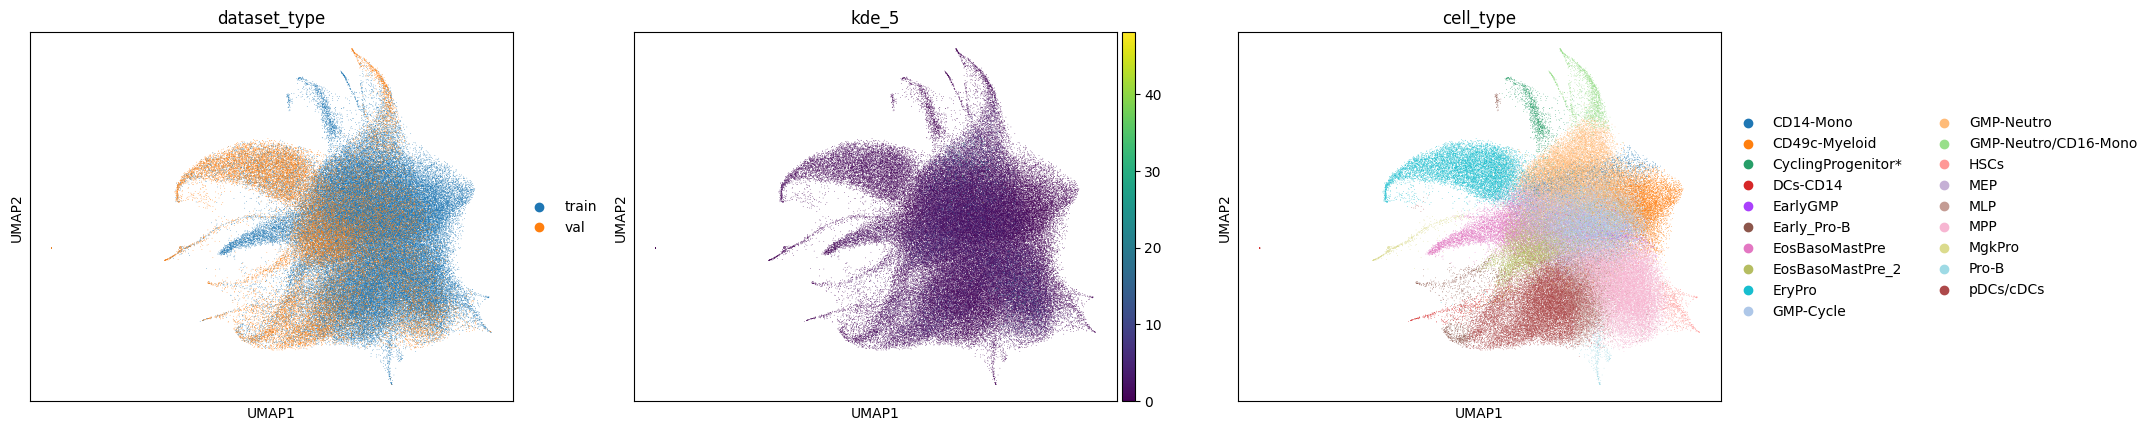

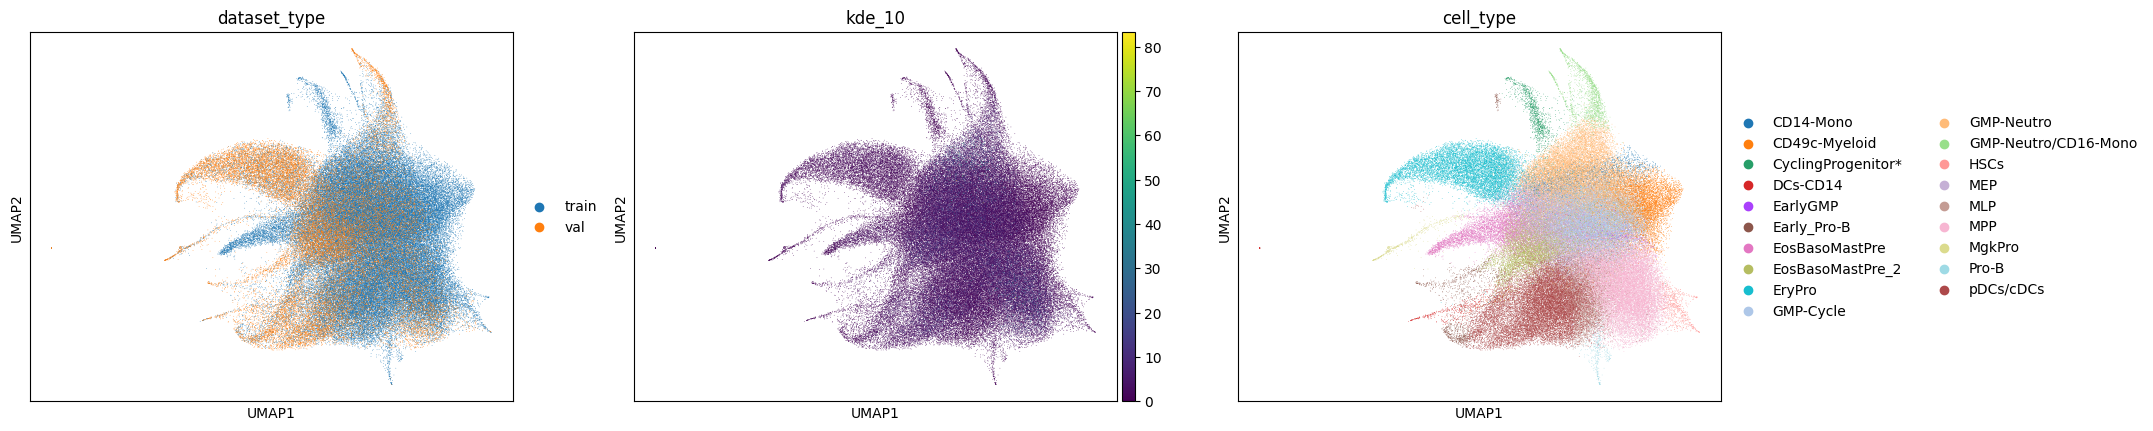

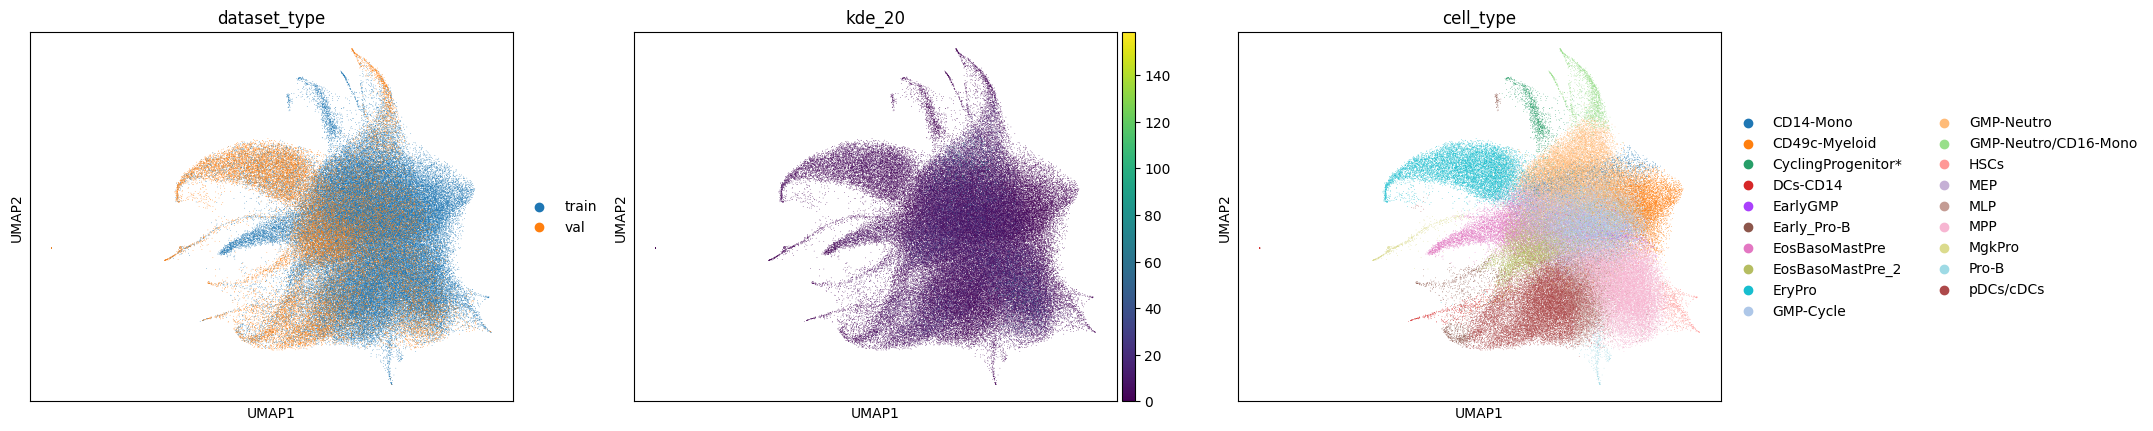

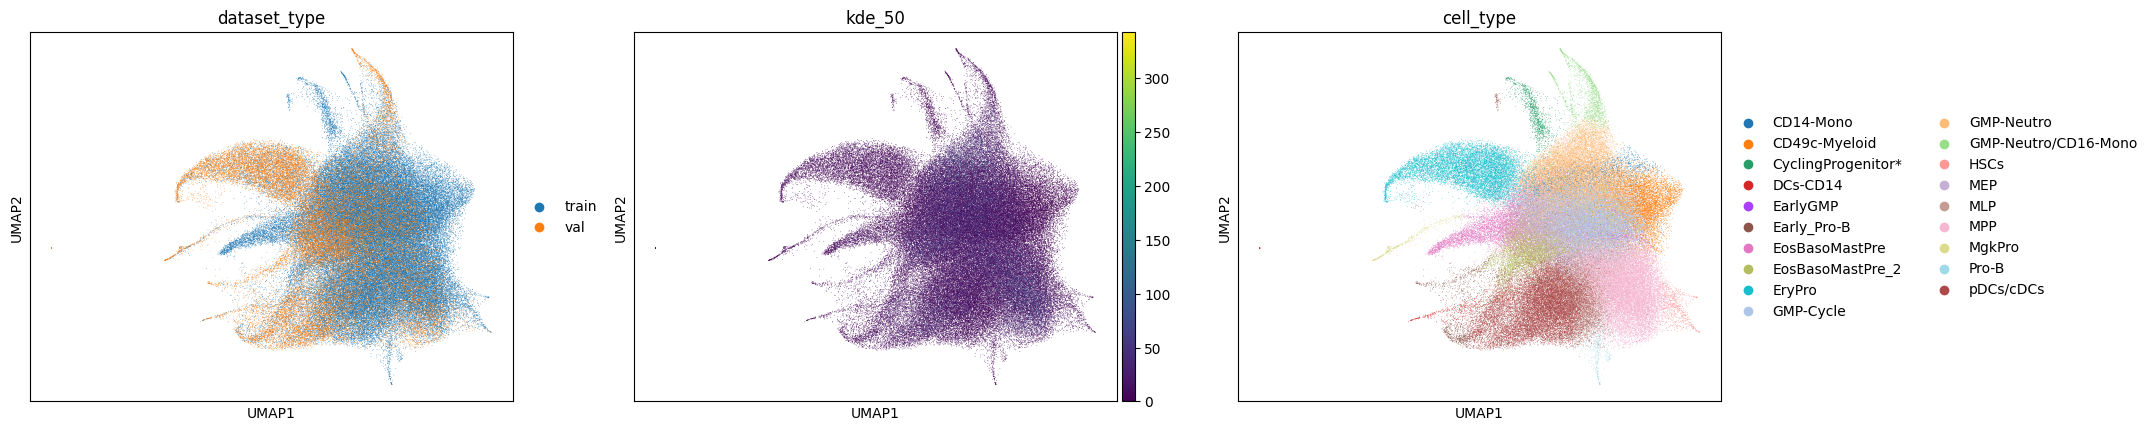

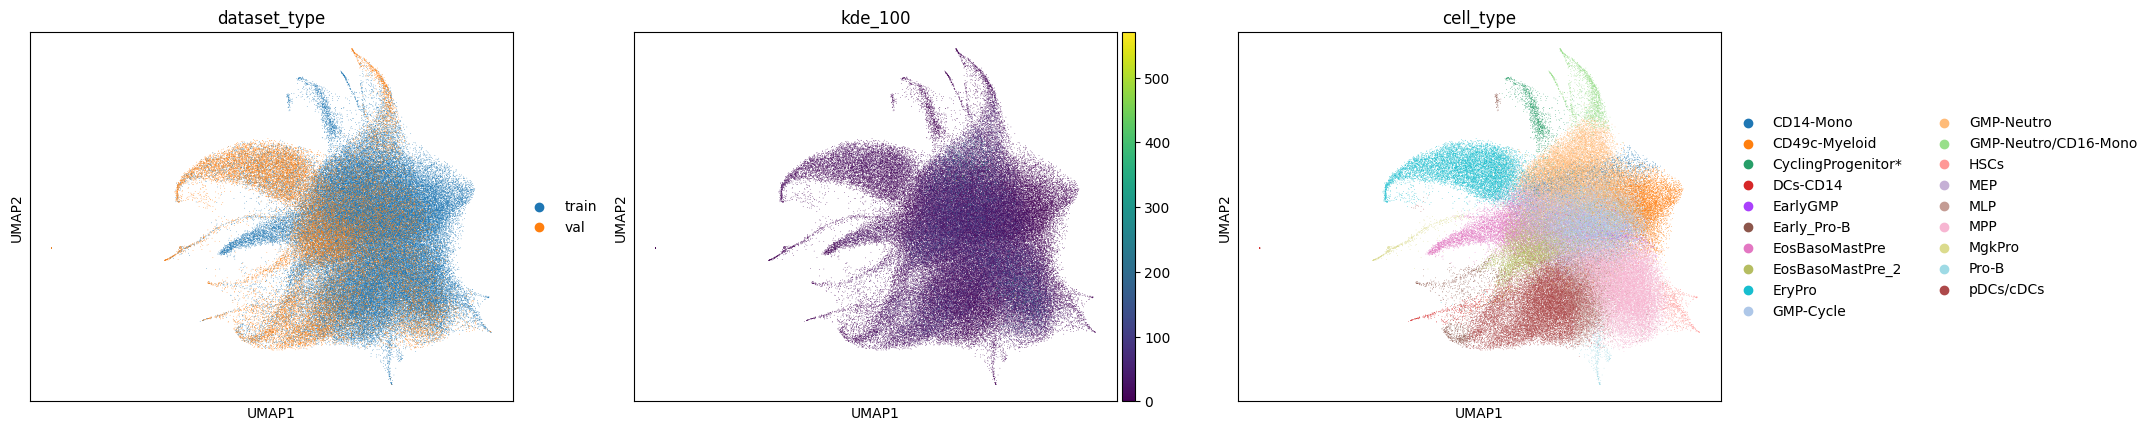

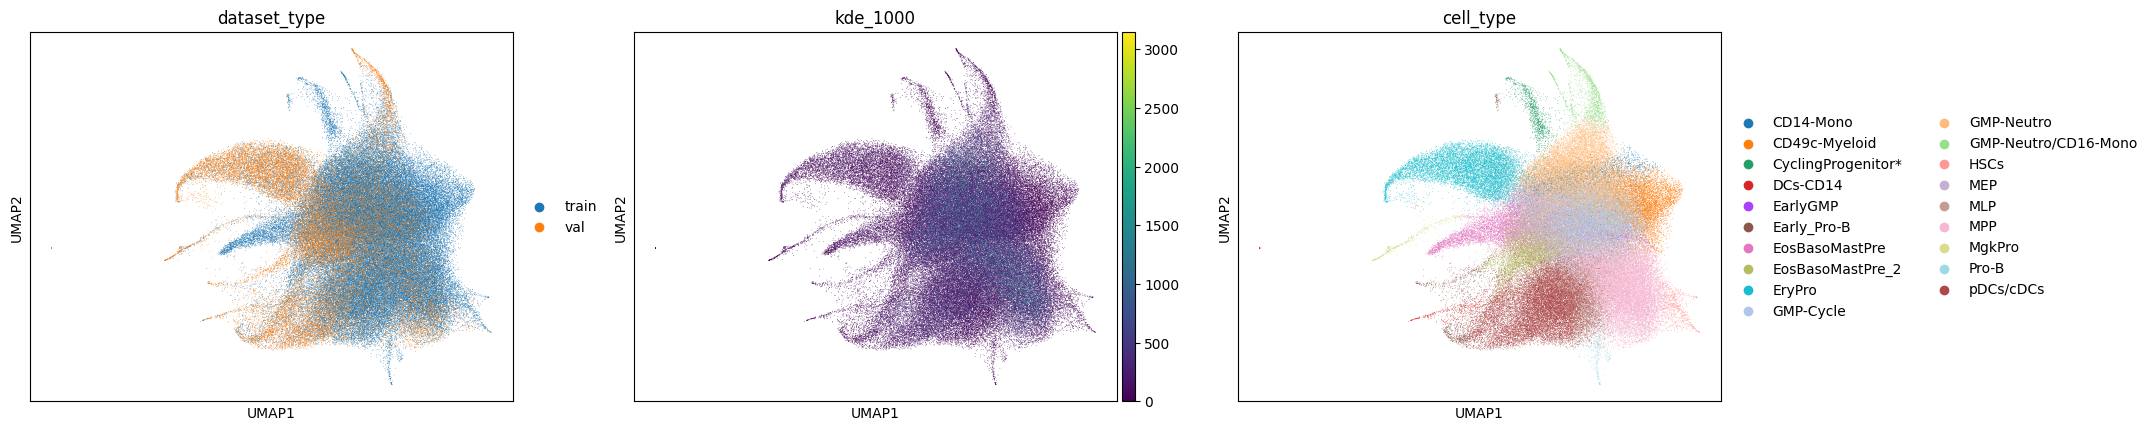

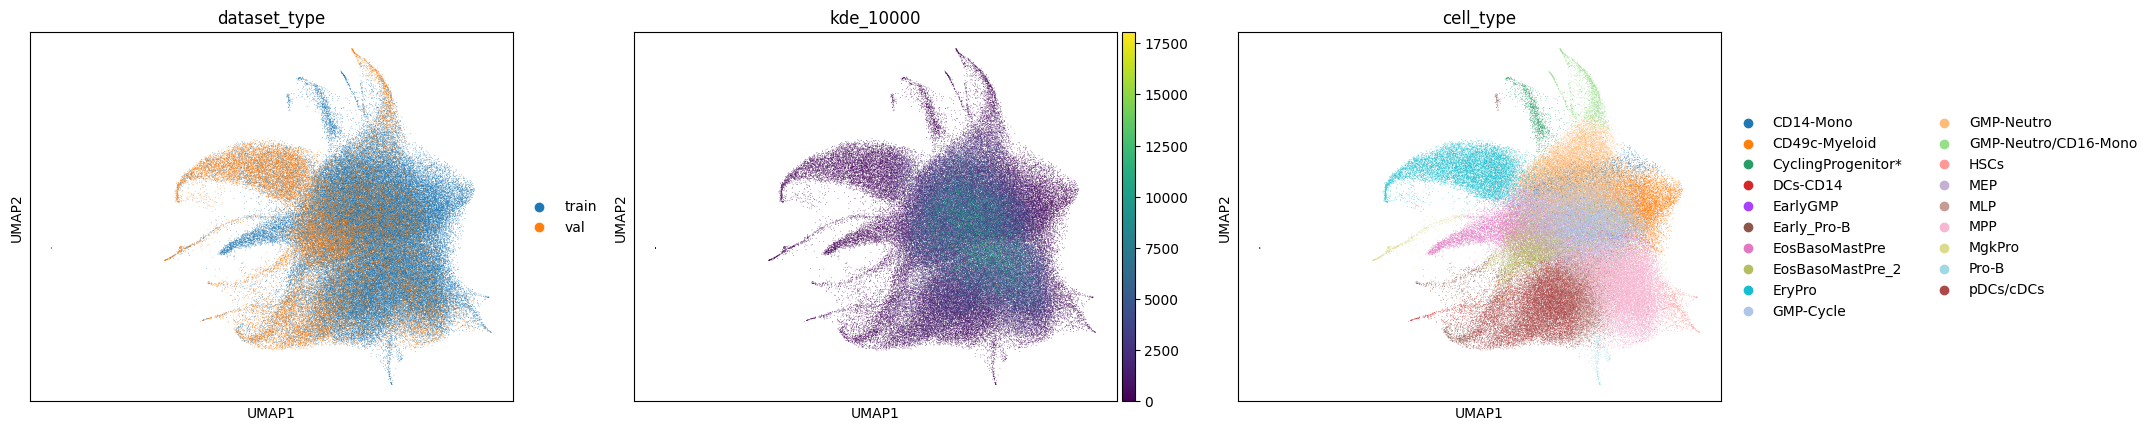

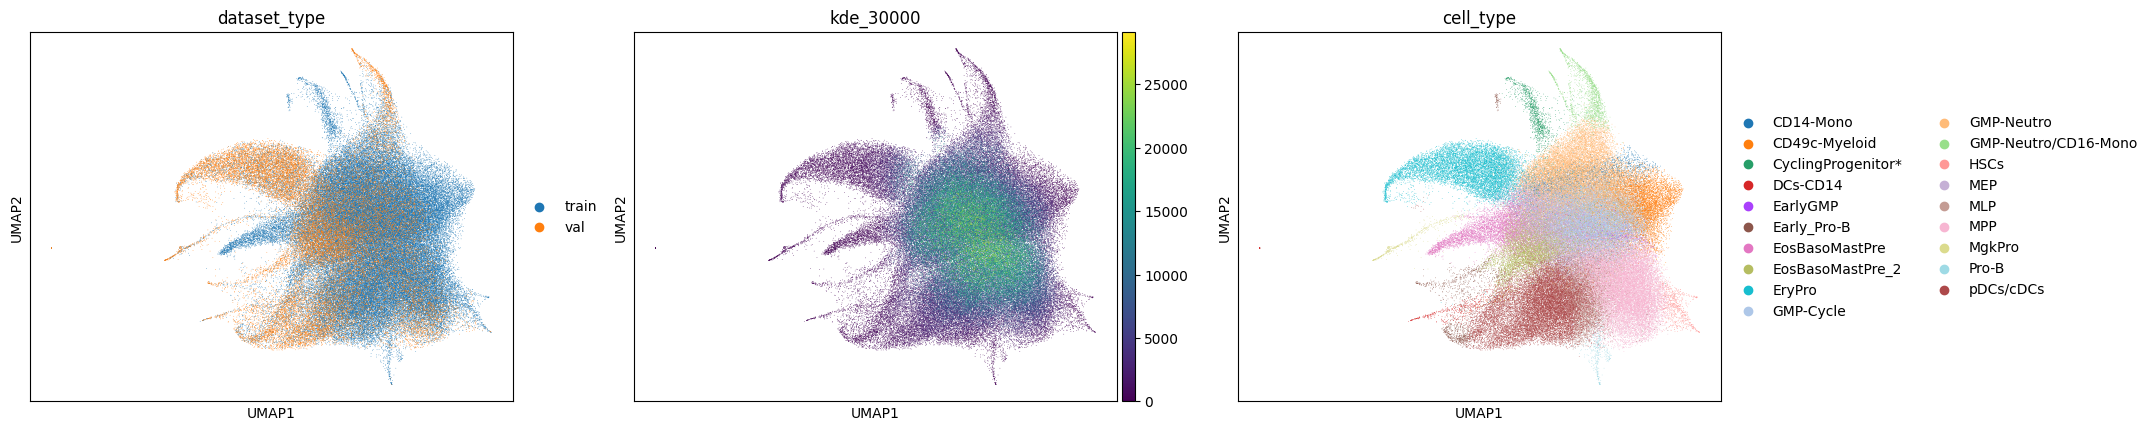

In [30]:
for k in K:
    sc.pl.embedding(adata_base, "umap", color=["dataset_type", f"kde_{k}", "cell_type"])

## Visualizing UMAP of concatenated data.

### Constructing Prediction `AnnData`.

In [31]:
# defining keys for the anndata
perturbation_obs_key = "protocol_id"
# concatenating with predictions
x_channel = np.concatenate(
    (
        X_channel_train,
        X_channel_val,
        X_channel,
    ), axis=0
)
x_scatter = np.concatenate(
    (
        X_scatter_train,
        X_scatter_val,
        X_scatter,
    ), axis=0
)

# preparing the annotations
obs = pd.DataFrame(
    {
        "dataset_type": [
            "in-distribution" for _ in range(len(train_adata_fwd))
        ] + [
            "ood" for _ in range(len(val_adata_fwd))
        ] + [
            "generated" for _ in range(len(X_channel))
        ],
        "is_generated": [
            False for _ in range(len(train_adata_fwd))
        ] + [
            False for _ in range(len(val_adata_fwd))
        ] + [
            True for _ in range(len(X_channel))
        ],
        "is_true_ood": [
            False for _ in range(len(train_adata_fwd))
        ] + [
            True for _ in range(len(val_adata_fwd))
        ] + [
            False for _ in range(len(X_channel))
        ],
        "cell_type": np.concatenate((G_label_train, G_label_val, G_label), axis=0),
    }
)
obsm = {
    "X_scatter": x_scatter,
}
var = pd.DataFrame(index=train_adata_fwd.var_names)

# creating adata
pred_adata_group = sc.AnnData(
    X=x_channel,
    obs=obs,
    obsm=obsm,
    var=var,
)

# computing pcs, neighbors, umap
sc.pp.pca(pred_adata_group)
sc.pp.neighbors(pred_adata_group)
sc.tl.umap(pred_adata_group)

/home/icb/lorenzo.consoli/miniconda3/envs/sc_exp_design/lib/python3.12/site-packages/anndata/_core/aligned_df.py:68: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)


### Plotting Umap.

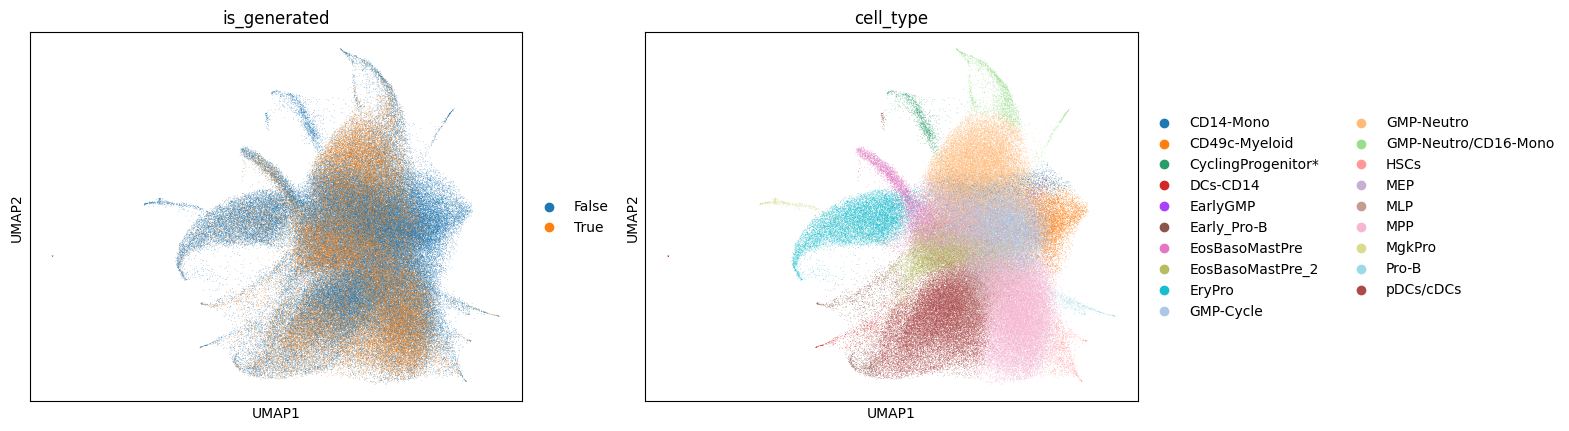

In [32]:
sc.pl.embedding(pred_adata_group, "umap", color=["is_generated", "cell_type"])

## Plotting marginals.

### Plotting Marginals of channel features.

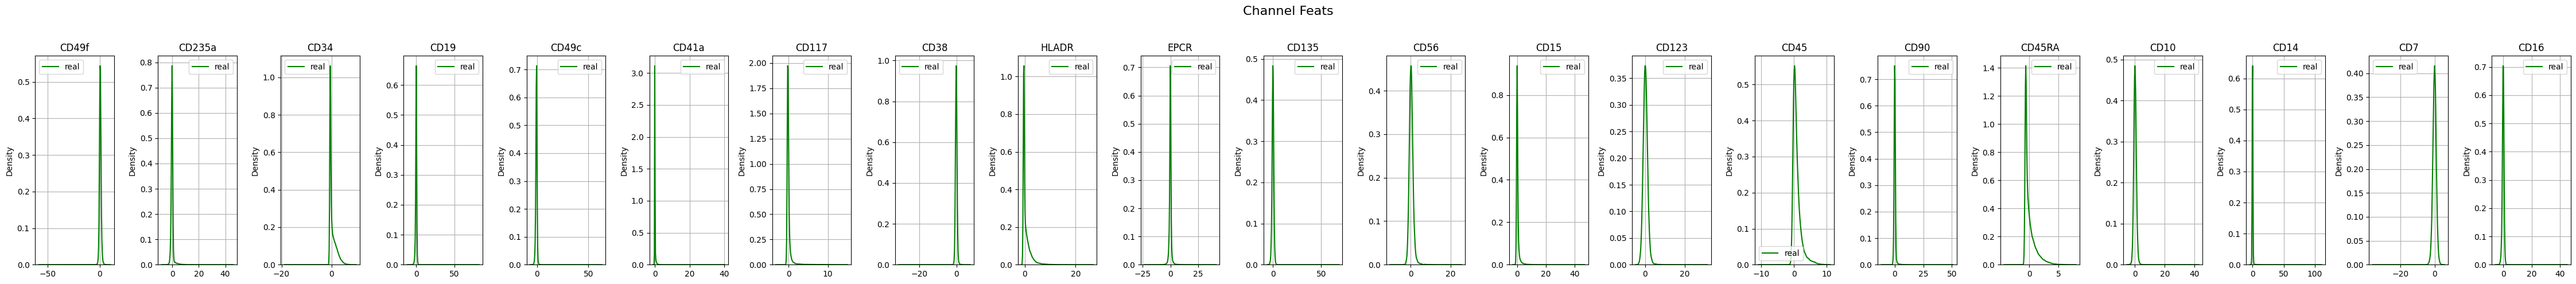

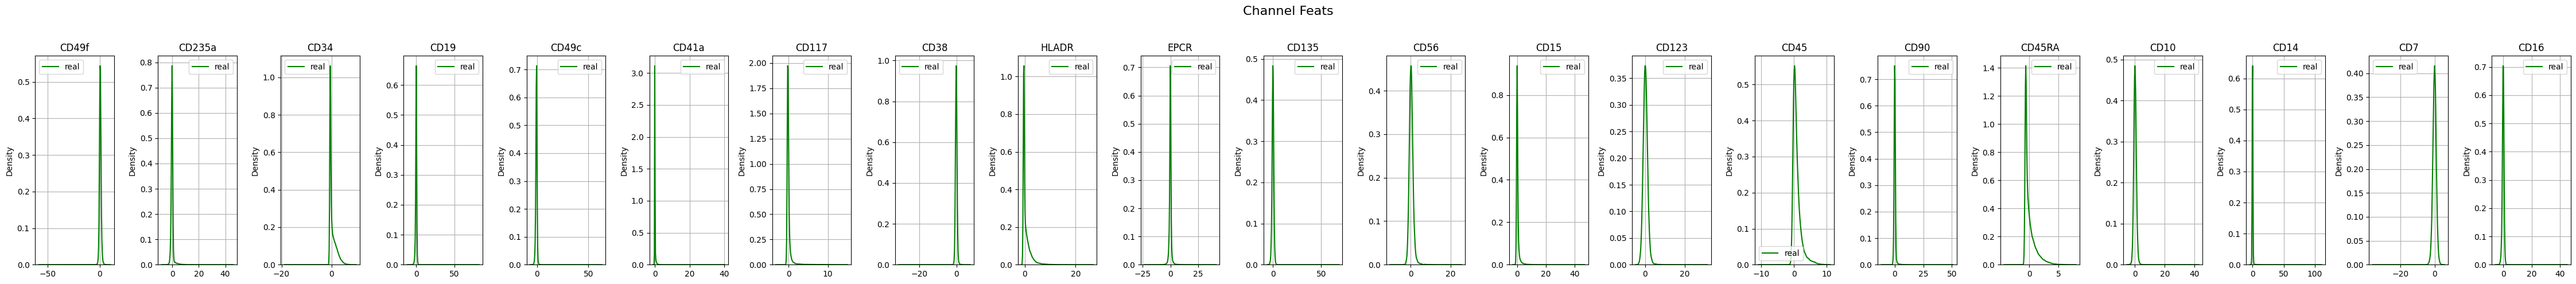

In [33]:
plot_marginals(X_channel, col_names=train_adata_fwd.var_names, title=f"Channel Feats")

### Plotting Marginals of scatter features.

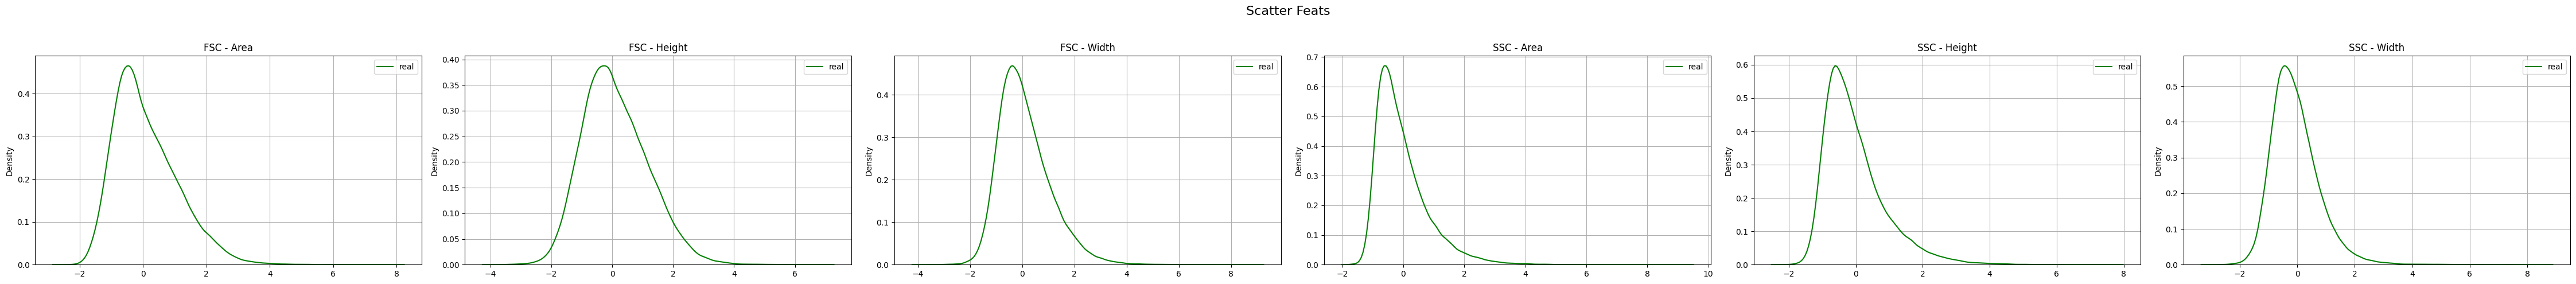

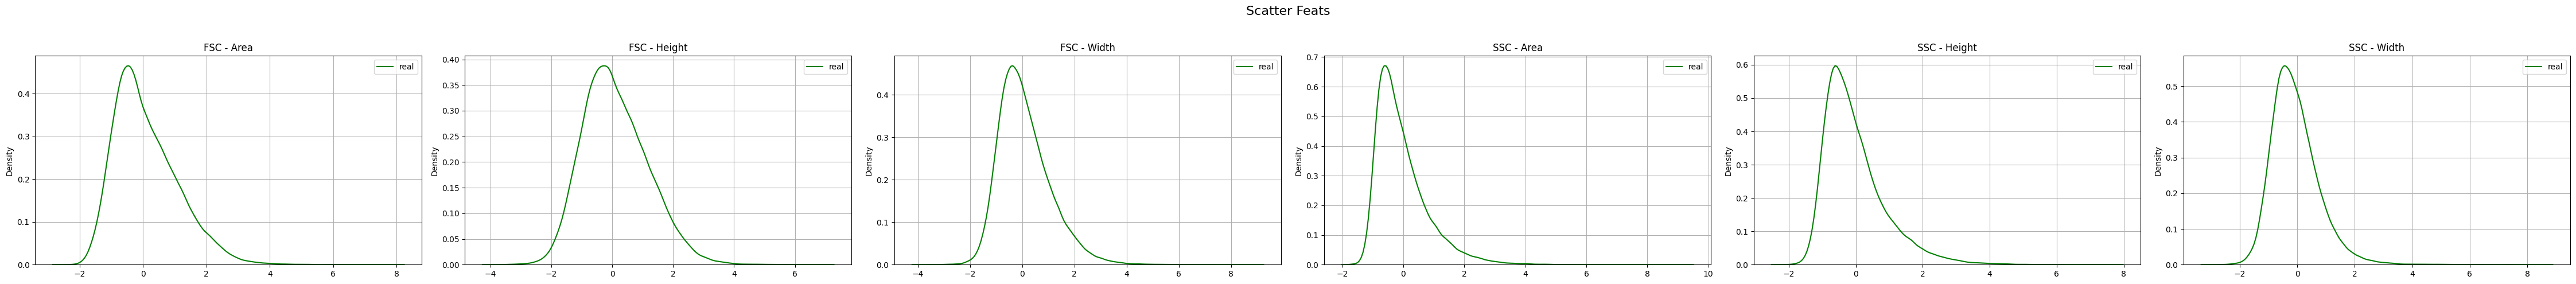

In [34]:
plot_marginals(X_scatter, col_names=scatter_columns, title=f"Scatter Feats")


## Analysing Generated cells.

### Displaying cell type composition.

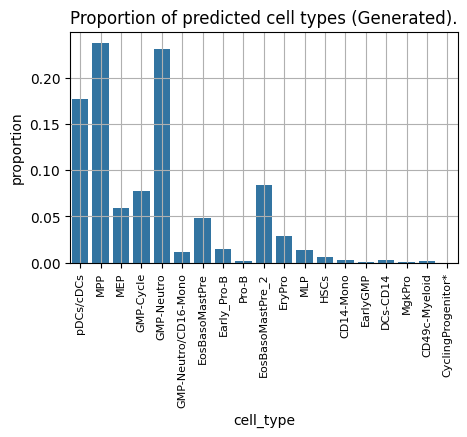

In [35]:
df = pd.DataFrame({"cell_type": G_label})
plt.figure(figsize=(5, 3))
plt.title("Proportion of predicted cell types (Generated).")
sns.countplot(data=df, x="cell_type", stat="proportion")
plt.xticks(rotation=90, fontsize=8)  # rotate labels if too crowded
plt.grid(1)
plt.show()


## Proportion of Positive Populations.

### Rescaling the generated cells.

In [36]:
X_hat_rescaled = izn(torch.from_numpy(X_hat).cuda()).detach().cpu().numpy()
X_channel_hat_resc = X_hat_rescaled[:, :-n_scatter_feats]
X_scatter_hat_resc = X_hat_rescaled[:, -n_scatter_feats:]
print(f"{X_hat_rescaled.shape=}, {X_channel_hat_resc.shape=}, {X_scatter_hat_resc.shape=}")

X_hat_rescaled.shape=(50000, 27), X_channel_hat_resc.shape=(50000, 21), X_scatter_hat_resc.shape=(50000, 6)


### Getting positive markers from train data.

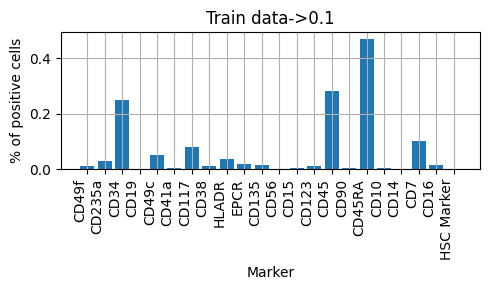

In [37]:
EPS = [1e-1]
for eps in EPS:
    X_channel_train_resc = train_adata_fwd.obsm[cell_state_rep]#[:, :-n_scatter_feats]
    X_channel_train_resc = izn(torch.from_numpy(X_channel_train_resc).cuda()).detach().cpu().numpy()
    X_channel_train_resc = X_channel_train_resc[:, :-n_scatter_feats]
    positives = (X_channel_train_resc > eps).astype(int)
    adata_gen = sc.AnnData(X=X_channel_train_resc, layers={"positives": positives}, var=pd.DataFrame(index=pred_adata_group.var_names))
    HSCs_markers = ["CD34", "CD45RA", "CD90", "EPCR"]
    markers = adata_gen.var_names.tolist() + ["HSC Marker"]
    hsc_positives = np.all(positives, axis=1)
    positives_full = np.concatenate((positives, hsc_positives[:, None]), axis=1)
    percentages = positives_full.mean(axis=0)
    plt.figure(figsize=(5, 3))
    plt.title(f"Train data->{eps}")
    plt.bar(markers, percentages)
    plt.ylabel("% of positive cells")
    plt.xlabel("Marker")
    plt.xticks(rotation=90, ha="right")
    plt.tight_layout()
    plt.grid(1)
    plt.show()

### Getting positive markers from generated data.

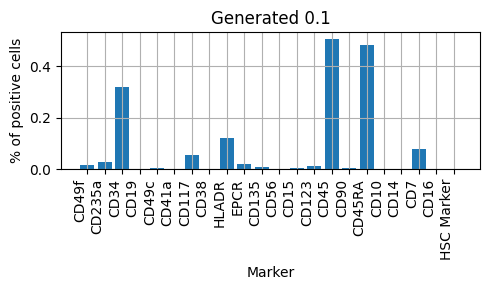

In [38]:
EPS = [1e-1]
for eps in EPS:
    positives = (X_channel_hat_resc > eps).astype(int)
    adata_gen = sc.AnnData(X=X_channel_hat_resc, layers={"positives": positives}, var=pd.DataFrame(index=pred_adata_group.var_names))
    HSCs_markers = ["CD34", "CD45RA", "CD90", "EPCR"]
    markers = adata_gen.var_names.tolist() + ["HSC Marker"]
    hsc_positives = np.all(adata_gen[:, HSCs_markers].layers["positives"], axis=1)
    positives_full = np.concatenate((positives, hsc_positives[:, None]), axis=1)
    percentages = positives_full.mean(axis=0)
    plt.figure(figsize=(5, 3))
    plt.title(f"Generated {eps}")
    plt.bar(markers, percentages)
    plt.ylabel("% of positive cells")
    plt.xlabel("Marker")
    plt.xticks(rotation=90, ha="right")
    plt.tight_layout()
    plt.grid(1)
    plt.show()

### Getting positive marker from train adata (positives).

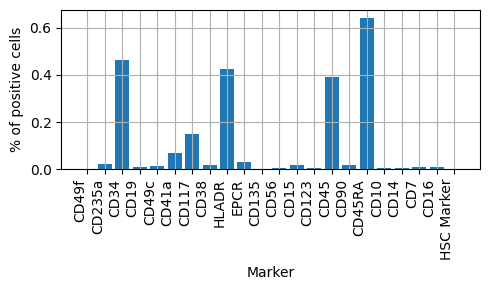

In [39]:
positives = (train_adata_fwd.layers["positives"] > 0).astype(int)
adata_gen = sc.AnnData(X=train_adata_fwd.X, layers={"positives": positives}, var=pd.DataFrame(index=pred_adata_group.var_names))
HSCs_markers = ["CD34", "CD45RA", "CD90", "EPCR"]
markers = adata_gen.var_names.tolist() + ["HSC Marker"]
hsc_positives = np.all(adata_gen[:, HSCs_markers].layers["positives"], axis=1)
positives_full = np.concatenate((positives, hsc_positives[:, None]), axis=1)
percentages = positives_full.mean(axis=0)
plt.figure(figsize=(5, 3))
plt.bar(markers, percentages)
plt.ylabel("% of positive cells")
plt.xlabel("Marker")
plt.xticks(rotation=90, ha="right")
plt.tight_layout()
plt.grid(1)
plt.show()

## Label transfer from annotated data.

Majority vote from $K=100$ nearest neighbors.

### Computing distance matrix.

In [40]:
D = cdist(X_hat, X_g)
D.shape

(50000, 100000)

### Sorting indices by distance.

In [41]:
sorted_idxs = D.argsort(1)
sorted_idxs.shape

(50000, 100000)

### Retrieving nearest neighbors.

In [42]:
K = 100
knn_idxs = sorted_idxs[:, :K]
knn_idxs

array([[75322, 47586, 12703, ..., 70944, 20867, 12739],
       [84910, 49801, 35957, ..., 41762, 63527, 12728],
       [94168, 26498, 51470, ..., 71362, 42491, 33790],
       ...,
       [35432, 11048, 12594, ...,  3270, 36304, 36461],
       [93765, 47835, 38713, ..., 51230, 15174, 75194],
       [99725, 93340, 92237, ..., 34419, 17847, 25773]],
      shape=(50000, 100))

### Retrieving annotations for KNN.

In [43]:
nn_leiden = []
for idx in range(knn_idxs.shape[0]):
    iidxs = knn_idxs[idx]
    ileiden = obs_df.loc[:, "leiden"].iloc[iidxs].value_counts(sort=False)
    nn_leiden.append(ileiden)
nn_leiden = np.stack(nn_leiden, axis=0)
nn_leiden.shape

(50000, 19)

### Retrieving the index of the cluster with maximum counts.

In [44]:
nn_leiden_argmax = nn_leiden.argmax(1)
nn_leiden_id = []
for idx in tqdm(range(nn_leiden_argmax.shape[0])):
    nn_leiden_id.append(ileiden.index[nn_leiden_argmax[idx]])
nn_leiden_id = np.array(nn_leiden_id)
nn_leiden_id

100%|██████████| 50000/50000 [00:00<00:00, 866731.42it/s]


array(['3', '0', '4', ..., '2', '0', '3'], shape=(50000,), dtype='<U2')

### Plotting distribution of leiden clusters.

<Axes: title={'center': '% Leiden clusters (Generated cells, 100-NN)'}, xlabel='leiden', ylabel='proportion'>

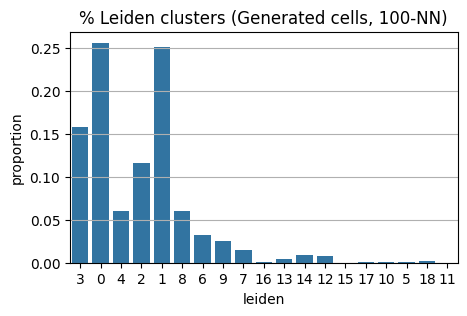

In [45]:
leiden_df = pd.DataFrame({"leiden": nn_leiden_id})
plt.figure(figsize=(5, 3))
plt.title(f"% Leiden clusters (Generated cells, {K}-NN)")
plt.grid(1)
sns.countplot(leiden_df, x="leiden", stat="proportion")

## Leiden Clusters Gene Expression.

### Rank genes per cluster (Real Data).

X_channel_g_iphi.shape=(100000, 21), X_scatter_g_iphi.shape=(100000, 6)


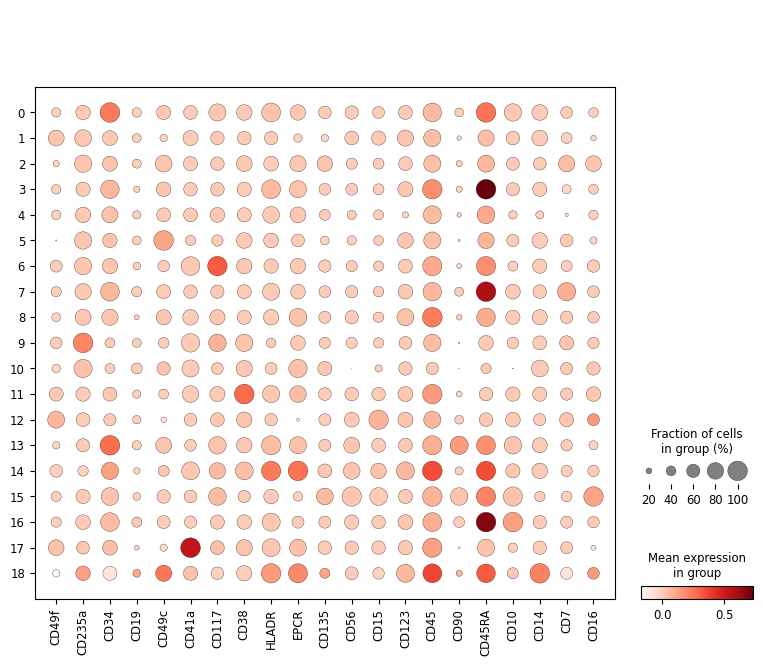

adata_annot_real=AnnData object with n_obs × n_vars = 100000 × 21
    obs: 'leiden'
    obsm: 'X_scatter'


In [46]:
X_g_iphi = izn(torch.from_numpy(X_g).cuda()).detach().cpu().numpy()
X_channel_g_iphi = X_g_iphi[:, :-n_scatter_feats]
X_scatter_g_iphi = X_g_iphi[:, -n_scatter_feats:]
print(f"{X_channel_g_iphi.shape=}, {X_scatter_g_iphi.shape=}")

adata_annot_real = sc.AnnData(
    X=X_channel_g_iphi,
    obs=obs_df.loc[:, ["leiden"]],
    obsm={"X_scatter": X_scatter_g_iphi},
    var=pd.DataFrame(index=train_adata_fwd.var_names)
)
sc.pl.dotplot(adata_annot_real, adata_annot_real.var_names, "leiden")
print(f"{adata_annot_real=}")

# sc.tl.rank_genes_groups(adata_annot_real, "leiden", method="wilcoxon")
# adata_annot_real

### 

### Rank genes per cluster (Generated Data).

X_channel_g_iphi.shape=(50000, 21), X_scatter_g_iphi.shape=(50000, 6)


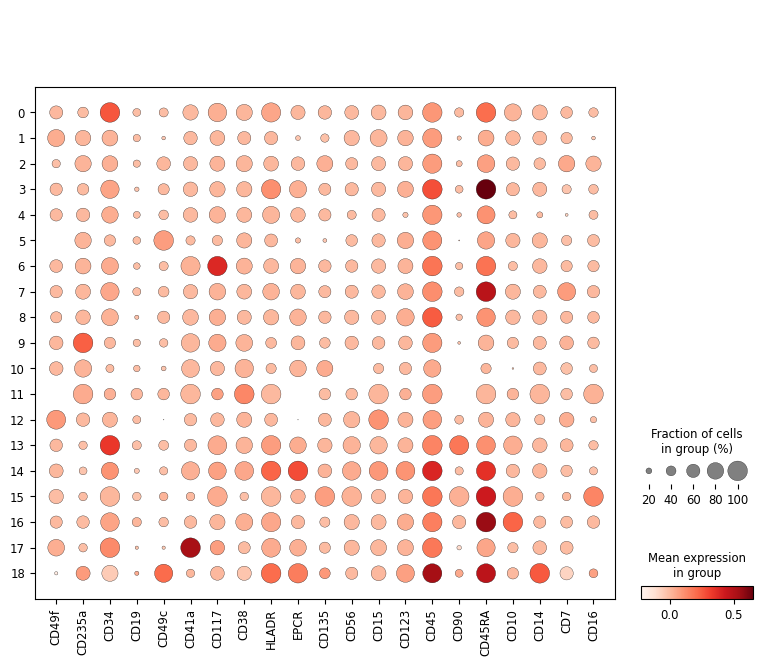

adata_annot_gen=AnnData object with n_obs × n_vars = 50000 × 21
    obs: 'leiden'
    obsm: 'X_scatter'


In [47]:
X_g_iphi = izn(torch.from_numpy(X_hat).cuda()).detach().cpu().numpy()
X_channel_g_iphi = X_g_iphi[:, :-n_scatter_feats]
X_scatter_g_iphi = X_g_iphi[:, -n_scatter_feats:]
print(f"{X_channel_g_iphi.shape=}, {X_scatter_g_iphi.shape=}")

adata_annot_gen = sc.AnnData(
    X=X_channel_g_iphi,
    obs={"leiden": nn_leiden_id},
    obsm={"X_scatter": X_scatter_g_iphi},
    var=pd.DataFrame(index=train_adata_fwd.var_names)
)
sc.pl.dotplot(adata_annot_gen, adata_annot_real.var_names, "leiden")
print(f"{adata_annot_gen=}")
# sc.tl.rank_genes_groups(adata_annot_gen, "leiden", method="t-test")
# adata_annot_gen